In [18]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import coherent, destroy
from scipy.special import eval_hermite, factorial

# Homodyne Detection for Binary Coherent-State Discrimination

We are considering the discrimination of two possible coherent states:

$$
|\psi_+\rangle = |\alpha\rangle,
\qquad
|\psi_-\rangle = |-\alpha\rangle
$$

These states encode a binary signal: the receiver knows that one of the two states was sent, but must determine which one based on the measurement outcome.

Homodyne detection provides a way of measuring a field quadrature. For the position-like quadrature, the quadrature operator is

$$
\hat{x}
=
\frac{\hat{a}+\hat{a}^\dagger}{\sqrt{2}},
$$

where $\hat{a}$ and $\hat{a}^\dagger$ are the annihilation and creation operators.

For real coherent amplitudes $\alpha$, the two coherent states are displaced in opposite directions along the $x$ quadrature. Therefore, a homodyne measurement of $\hat{x}$ produces two probability distributions centred on opposite sides of the origin.

The measurement outcome $x$ is continuous. To decide which state was sent, we use a decision boundary at

$$
x=0.
$$

For equal prior probabilities:

If $x > 0$, we decide that $|\alpha\rangle$ was sent.

If $x < 0$, we decide that $|-\alpha\rangle$ was sent.

However, the two probability distributions overlap. Therefore, some measurement outcomes can lead to an incorrect decision. This overlap gives rise to the homodyne detection error probability.

First we need to constroy the quadrature operator, which means we should check if it is rightfully defined as well as the Qutip coherent function, so we can check it by measuring our states with the operator and find out if the result is as expected. 

In [2]:
N = 30
alpha = 0.7

psi_plus = coherent(N, alpha)
psi_minus = coherent(N, -alpha)

In [ ]:
# Creation operator
a = destroy(N)

In [ ]:
# Quadrature operator
X = (a + a.dag()) / np.sqrt(2)

In [9]:
X_plus = (psi_plus.dag() * X * psi_plus).real
X_minus = (psi_minus.dag() * X * psi_minus).real

print("⟨X⟩ for |+α⟩ =", X_plus)
print("⟨X⟩ for |-α⟩ =", X_minus)
print("√2 * α =", np.sqrt(2) * alpha)

⟨X⟩ for |+α⟩ = 0.9899494936611666
⟨X⟩ for |-α⟩ = -0.9899494936611666
√2 * α = 0.9899494936611666


We can conclude everything is working as expected.

## Defining the Binary Coherent States

We work in a truncated Fock basis of dimension

$$
N=40
$$

In this example, the coherent-state amplitude is chosen as

$$
\alpha = 0.7
$$

Since $\alpha$ is real, the two states are displaced in opposite directions along the x axis.

We also define a range of possible homodyne measurement outcomes,

$$
x \in [-5,5]
$$

The variable $x$ represents the continuous outcome obtained when measuring the quadrature $\hat{x}$.

In [14]:
N = 40
alpha = 0.7

psi_plus = coherent(N, alpha)
psi_minus = coherent(N, -alpha)

# Quadrature values
x = np.linspace(-5, 5, 1000)

## Quadrature Wavefunctions of Fock States

The coherent states generated by QuTiP are represented in the Fock basis,

$$
|\psi\rangle
=
\sum_{n=0}^{N-1} c_n |n\rangle
$$

To obtain the probability distribution of a quadrature measurement, we need to express the state in the continuous quadrature basis $|x\rangle$.

The quadrature wavefunction of a Fock state $|n\rangle$ is

$$
\langle x|n\rangle
=
\frac{1}
{\pi^{1/4}\sqrt{2^n n!}}
H_n(x)
e^{-x^2/2}
$$

where $H_n(x)$ is the nth Hermite polynomial.

The function fock_wavefunction(n, x) implements this expression and returns

$$
\langle x|n\rangle
$$

which describes the probability amplitude for obtaining the quadrature value $x$ when the system is in the Fock state $|n\rangle$.

In [15]:
#Position/quadrature wavefunction <x|n> for the harmonic oscillator.

def fock_wavefunction(n, x):
    normalization = (1/ (np.pi**0.25 * np.sqrt(2**n * factorial(n))))

    return (normalization* eval_hermite(n, x)* np.exp(-x**2 / 2))

## Constructing the Quadrature Wavefunction

The quantum states $|\alpha\rangle$ and $|-\alpha\rangle$ are represented numerically in the Fock basis. To simulate a homodyne measurement, we transform them into the quadrature representation.

Starting from

$$
|\psi\rangle
=
\sum_n \langle n|\psi\rangle |n\rangle
$$

we project the state onto the quadrature eigenstate $|x\rangle$:

$$
\langle x|\psi\rangle
=
\sum_n
\langle x|n\rangle
\langle n|\psi\rangle
$$

Therefore, the quadrature wavefunction is

$$
\psi(x)
=
\langle x|\psi\rangle
=
\sum_n c_n \langle x|n\rangle
$$

where

$$
c_n=\langle n|\psi\rangle
$$

is the coefficient of the Fock state $|n\rangle$.

The function quadrature_wavefunction performs this summation numerically for every value of $x$.

In [16]:
#Calculate the quadrature wavefunction psi(x) = <x|psi> from a QuTiP state written in the Fock basis.

def quadrature_wavefunction(state, x):
    N = state.shape[0]
    psi_x = np.zeros_like(x, dtype=complex)

    for n in range(N):
        # Coefficient <n|psi>
        coefficient = state[n, 0]
        # <x|psi> = sum_n <x|n><n|psi>
        psi_x += coefficient * fock_wavefunction(n, x)

    return psi_x

## Homodyne Probability Distributions

Once the quadrature wavefunctions have been calculated, we use the Born rule to obtain the probability densities:

$$
P(x|+\alpha)
=
|\langle x|\alpha\rangle|^2
$$

and

$$
P(x|-\alpha)
=
|\langle x|-\alpha\rangle|^2
$$

These distributions describe the probability density for obtaining a particular homodyne measurement outcome $x$, depending on which coherent state was sent.

For a coherent state with a real amplitude $\alpha$, the quadrature probability distribution is a Gaussian distribution. The states $|\alpha\rangle$ and $|-\alpha\rangle$ are centred at opposite values of the measured quadrature.

The difficulty of distinguishing two quantum states is determined by their overlap. For two coherent states, the overlap is

$$
\langle \alpha | \beta \rangle
=
\exp\left(
-\frac{|\alpha|^2}{2}
-\frac{|\beta|^2}{2}
+\alpha^*\beta
\right)
$$

For the two states $|+\alpha\rangle\quad \text{and} \quad|-\alpha\rangle$, we obtain

$$
\langle +\alpha|-\alpha\rangle
=
\exp(-2|\alpha|^2)
$$

So the squared overlap is

$$
\left|
\langle +\alpha|-\alpha\rangle
\right|^2
=
\exp(-4|\alpha|^2)
$$

When $|\alpha|$ is small, the two coherent states strongly overlap and are difficult to distinguish.

As $|\alpha|$ increases, the overlap becomes smaller and the states become easier to distinguish.

## The Helstrom bound

For discrimination between two quantum states with equal prior probabilities, the minimum possible probability of making an error is given by the Helstrom bound:

$$
P_{\mathrm{Hel}}
=
\frac{1}{2}
\left(
1-
\sqrt{
1-
\left|
\langle \psi_0|\psi_1\rangle
\right|^2
}
\right)
$$

For the coherent states $|\psi_0\rangle = |+\alpha\rangle$ and  $|\psi_1\rangle = |-\alpha\rangle,$ we have

$$
\left|
\langle +\alpha|-\alpha\rangle
\right|^2
=
e^{-4|\alpha|^2}
$$

Substituting this into the Helstrom bound gives

$$
P_{\mathrm{Hel}}
=
\frac{1}{2}
\left(
1-
\sqrt{
1-e^{-4|\alpha|^2}
}
\right)
$$

This represents the *ideal minimum error probability* for distinguishing the states $|+\alpha\rangle$ and $|-\alpha\rangle$.

In [20]:
psi_x_plus = quadrature_wavefunction(psi_plus, x)

psi_x_minus = quadrature_wavefunction(psi_minus, x)

P_plus = np.abs(psi_x_plus)**2
P_minus = np.abs(psi_x_minus)**2

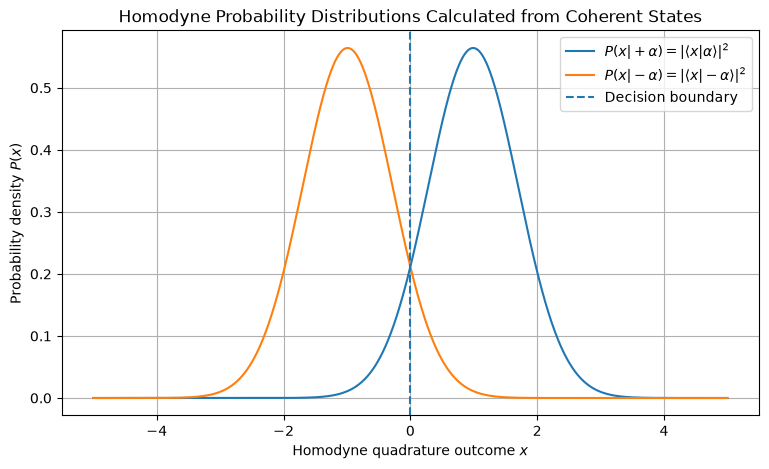

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(x, P_plus, label=r"$P(x|+\alpha)=|\langle x|\alpha\rangle|^2$")
plt.plot(x, P_minus, label=r"$P(x|-\alpha)=|\langle x|-\alpha\rangle|^2$")

plt.axvline(0, linestyle="--", label="Decision boundary")

plt.xlabel(r"Homodyne quadrature outcome $x$")
plt.ylabel(r"Probability density $P(x)$")

plt.title("Homodyne Probability Distributions Calculated from Coherent States")

plt.legend()
plt.grid()
plt.show()

## Homodyne Decision Rule

The vertical line at

$$
x=0
$$

represents the decision boundary of the homodyne receiver.

Because the two coherent states are symmetrically displaced around the origin, the optimal decision boundary for equal prior probabilities is located at $x=0$.

The decision rule is therefore

$$
x>0
\quad \Rightarrow \quad
|\alpha\rangle
$$

and

$$
x<0
\quad \Rightarrow \quad
|-\alpha\rangle
$$

An error occurs when the state $|\alpha\rangle$ produces a measurement outcome $x<0$, or when the state $|-\alpha\rangle$ produces an outcome $x>0$.

Thus, the error probability is determined by the area of the probability distributions on the wrong side of the decision boundary.

For equal prior probabilities, the total error probability can be written as

$$
P_{\mathrm{err}}
=
\frac{1}{2}
\left[
P(x<0|\alpha)
+
P(x>0|-\alpha)
\right]
$$

Due to the symmetry of the two distributions, these two contributions are equal.

## Theoretical Homodyne Error Probability

For binary coherent-state discrimination using homodyne detection, the overlap between the two quadrature probability distributions determines the probability of making an incorrect decision.

For the two coherent states with equal prior probabilities, the theoretical error probability is

$$
P_{\mathrm{hom}}
=
\frac{1}{2}
\operatorname{erfc}
\left(
\sqrt{2}|\alpha|
\right)
$$

where $\operatorname{erfc}(x)$ is the complementary error function,

$$
\operatorname{erfc}(x)
=
\frac{2}{\sqrt{\pi}}
\int_x^\infty
e^{-t^2}\,dt
$$

This expression results from integrating the Gaussian tail of the quadrature probability distribution over the incorrect decision region.

When $|\alpha|=0$, the two coherent states are identical:

$$
|+\alpha\rangle=|-\alpha\rangle=|0\rangle
$$

In this case, the receiver cannot distinguish between them, and the error probability is

$$
P_{\mathrm{hom}}=\frac{1}{2}
$$

As $|\alpha|$ increases, the distributions become increasingly separated. Their overlap decreases, and therefore the homodyne error probability approaches zero.

In [22]:
error_plus = np.mean(P_plus < 0)
error_minus = np.mean(P_minus > 0)

P_error_homodyne = 0.5 * (error_plus + error_minus)

print("Homodyne error probability =", P_error_homodyne)

Homodyne error probability = 0.5


## Comparison with homodyne detection

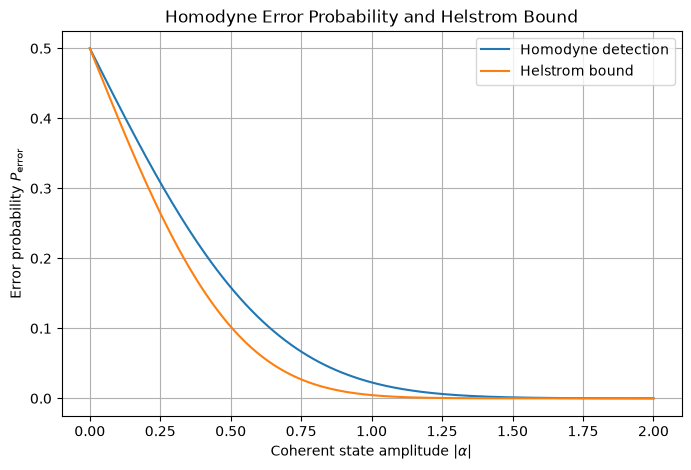

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# Range of coherent state amplitudes

alphas = np.linspace(0, 2, 200)

# Theoretical homodyne error probability

P_hom_theory = 0.5 * erfc(np.sqrt(2) * np.abs(alphas))

# Helstrom bound error probability

P_helstrom = 0.5 * (1 - np.sqrt(1 - np.exp(-4 * np.abs(alphas)**2)))

# Plot

plt.figure(figsize=(8, 5))
plt.plot(alphas, P_hom_theory, label="Homodyne detection")
plt.plot(alphas, P_helstrom, label="Helstrom bound")

plt.xlabel(r"Coherent state amplitude $|\alpha|$")
plt.ylabel(r"Error probability $P_{\mathrm{error}}$")
plt.title("Homodyne Error Probability and Helstrom Bound")

plt.grid(True)
plt.legend()
plt.show()